# Full Pipeline 02: DQN Training with HMM + News Features

This notebook is the canonical RL training path for the merged pipeline.

- HMM regime source: `output/full_pipeline/hmm_regimes_full_sample.csv`
- RL state: price + macro + filtered HMM posteriors + 5 weekly FinBERT features
- RL algorithm: DQN only
- Exported outputs: `rl_validation_actions.csv` and `rl_locked_test_actions.csv`


In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "full_pipeline").exists() and (candidate / "scripts").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repo root.")

PIPELINE_ROOT = REPO_ROOT / "full_pipeline"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from evaluation import EvaluationConfig
from ml.training_utils import evaluate_episode, train_dqn_finrl
from _pipeline_utils import (
    OUTPUT_DIR,
    make_rl_env,
    prepare_rl_inputs,
    rollout_agent_on_split,
    save_action_frame,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)


In [2]:
FAST_MODE = True
TOTAL_TIMESTEPS = 4_000 if FAST_MODE else 30_000
EVAL_FREQ = 500 if FAST_MODE else 2_000
EARLY_STOPPING_PATIENCE = 6 if FAST_MODE else 10
BUFFER_SIZE = 5_000 if FAST_MODE else 10_000
SEQ_LEN = 4

print(
    f"FAST_MODE={FAST_MODE} | timesteps={TOTAL_TIMESTEPS} | "
    f"eval_freq={EVAL_FREQ} | buffer={BUFFER_SIZE}"
)


FAST_MODE=True | timesteps=4000 | eval_freq=500 | buffer=5000


## Load the Merged RL State

The state comes from notebook 01 and preserves the evaluation split boundaries:

- `train` through 2020-12-31
- `validation` through 2022-12-30
- `locked_test` after 2022-12-30


In [3]:
prepared = prepare_rl_inputs()
dataset = prepared["dataset"]
frame = prepared["frame"]

display(dataset.describe_splits())
display(dataset.describe_feature_blocks())

print("Continuous RL feature columns:", len(prepared["feature_cols"]))
print("Posterior columns:", prepared["posterior_cols"])
display(frame.loc[:, ["week_end", "eval_split", *prepared["posterior_cols"][:2]]].head(3))


,split,rows,start,end
0,warmup,14,2014-03-28,2014-06-27
1,train,339,2014-07-04,2020-12-25
2,validation,105,2021-01-01,2022-12-30
3,locked_test,167,2023-01-06,2026-03-13


,block,n_columns,example_columns
0,price,35,"spy_ret_1d, spy_ret_5d, spy_ret_20d, spy_vol_5..."
1,macro,31,"bamlh0a0hym2_level, bamlh0a0hym2_chg_5d, cfnai..."
2,regime,4,"regime_filtered, regime_viterbi, filtered_prob..."
3,text,5,"news_finbert_compound_spy, news_finbert_compou..."


Continuous RL feature columns: 71
Posterior columns: ['filtered_prob_regime_0', 'filtered_prob_regime_1']


,week_end,eval_split,filtered_prob_regime_0,filtered_prob_regime_1
0,2014-03-28,warmup,1.191012e-15,1.000000
1,2014-04-04,warmup,4.107824e-02,0.958922
2,2014-04-11,warmup,4.290745e-02,0.957093


In [4]:
train_mask = frame["eval_split"] == "train"
scaled_train = prepared["scaled_features"].loc[train_mask, prepared["feature_cols"]]

scaling_checks = pd.DataFrame(
    {
        "train_mean_abs_max": [float(np.abs(scaled_train.mean()).max())],
        "train_std_min": [float(scaled_train.std(ddof=0).min())],
        "train_std_max": [float(scaled_train.std(ddof=0).max())],
    }
)
display(scaling_checks)


,train_mean_abs_max,train_std_min,train_std_max
0,4.191993e-15,1.0,1.0


In [5]:
eval_config = EvaluationConfig(
    transaction_cost=0.001,
    risk_penalty=0.05,
    risk_window=12,
)

train_env = make_rl_env(prepared, split="train", seq_len=SEQ_LEN, config=eval_config)
val_env = make_rl_env(prepared, split="validation", seq_len=SEQ_LEN, config=eval_config)
test_env = make_rl_env(prepared, split="locked_test", seq_len=SEQ_LEN, config=eval_config)

print("Train action names:", train_env.ACTION_NAMES)
print("Train observation space:", train_env.observation_space)
print("Train action space:", train_env.action_space)


Train action names: ['cash_only', 'spy_only', 'tlt_only', 'gld_only', 'spy_80_tlt_20', 'balanced_60_30_10', 'defensive_20_60_20']
Train observation space: Box(-inf, inf, (4, 77), float32)
Train action space: Discrete(7)


## Train the Canonical DQN Agent

The mainline merged pipeline uses DQN only. PPO/A2C/native-attention remain in the legacy experimentation notebook.


In [6]:
training = train_dqn_finrl(
    train_env=train_env,
    val_env=val_env,
    total_timesteps=TOTAL_TIMESTEPS,
    eval_freq=EVAL_FREQ,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    learning_rate=1e-4,
    exploration_fraction=0.15,
    exploration_final_eps=0.05,
    target_update_interval=1_000,
    buffer_size=BUFFER_SIZE,
    batch_size=32,
    device="auto",
)

agent = training["agent"]
print("Best validation reward:", training["best_val_reward"])
pd.DataFrame(training["val_history"]).head()


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Validation at step 500: reward=-0.2081

-> New best validation reward!

Validation at step 1000: reward=-0.2081

=== Training DQN Agent with FinRL ===
Device: cpu
Total timesteps: 4000
Evaluation frequency: 500
Early stopping patience: 6



...

-> New best validation reward!

Validation at step 3500: reward=-0.1541

Validation at step 4000: reward=-0.2239

Best validation reward: -0.1187637110401347


,step,reward
0,500,-0.208095
1,1000,-0.208095
2,1500,-0.211051
3,2000,-0.225441
4,2500,-0.146752


In [7]:
validation_eval = evaluate_episode(agent, val_env, deterministic=True)
locked_test_eval = evaluate_episode(agent, test_env, deterministic=True)

eval_table = pd.DataFrame(
    [
        {"split": "validation", **validation_eval},
        {"split": "locked_test", **locked_test_eval},
    ]
)
eval_table.loc[:, ["split", "reward", "length", "cumulative_return", "sharpe_ratio", "max_drawdown"]]


,split,reward,length,cumulative_return,sharpe_ratio,max_drawdown
0,validation,-0.223900,105,-0.096121,-0.275012,-0.182414
1,locked_test,0.233384,167,0.440160,1.395812,-0.047994


In [8]:
validation_export_env = make_rl_env(prepared, split="validation", seq_len=SEQ_LEN, config=eval_config)
locked_test_export_env = make_rl_env(prepared, split="locked_test", seq_len=SEQ_LEN, config=eval_config)

validation_actions = rollout_agent_on_split(agent, validation_export_env, frame, "validation")
locked_test_actions = rollout_agent_on_split(agent, locked_test_export_env, frame, "locked_test")

validation_path = save_action_frame(validation_actions, OUTPUT_DIR / "rl_validation_actions.csv")
locked_test_path = save_action_frame(locked_test_actions, OUTPUT_DIR / "rl_locked_test_actions.csv")

print("Saved:")
print(" ", validation_path.relative_to(REPO_ROOT))
print(" ", locked_test_path.relative_to(REPO_ROOT))

display(validation_actions.head(3))
display(locked_test_actions.head(3))


Saved:
  output/full_pipeline/rl_validation_actions.csv
  output/full_pipeline/rl_locked_test_actions.csv


,week_end,eval_split,action_id,action_name,reward,portfolio_return,turnover,transaction_cost
0,2021-01-01,validation,0,cash_only,0.000017,0.000017,0.0,0.0000
1,2021-01-08,validation,4,spy_80_tlt_20,-0.013178,-0.011006,1.0,0.0010
2,2021-01-15,validation,1,spy_only,0.017822,0.019111,0.2,0.0002


,week_end,eval_split,action_id,action_name,reward,portfolio_return,turnover,transaction_cost
0,2023-01-06,locked_test,0,cash_only,0.000829,0.000833,0.0,0.0
1,2023-01-13,locked_test,0,cash_only,0.000829,0.000833,0.0,0.0
2,2023-01-20,locked_test,0,cash_only,0.000830,0.000833,0.0,0.0


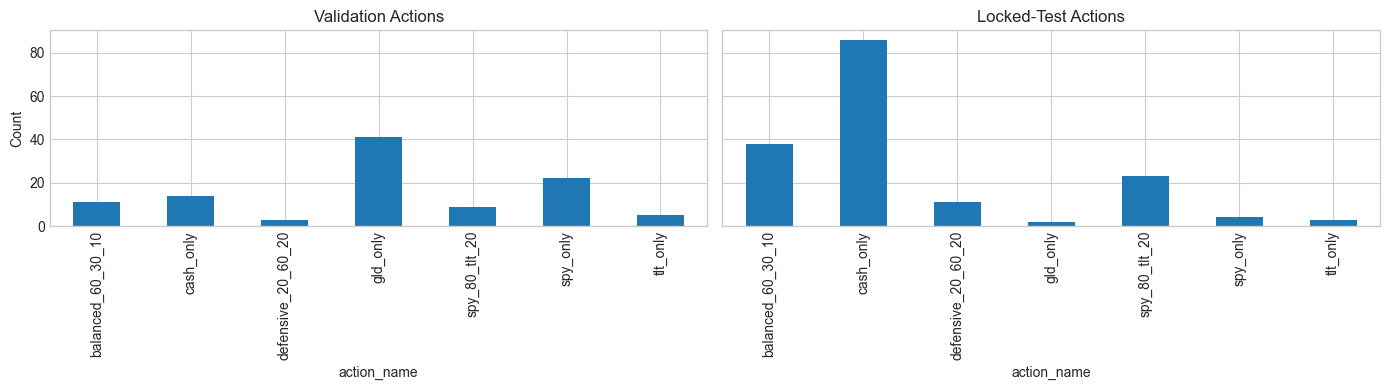

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
validation_actions["action_name"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Validation Actions")
locked_test_actions["action_name"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Locked-Test Actions")
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()
